# Task 1: Graph Concepts & State Design
LangGraph is a framework for building stateful and multi-step AI agent workflows. Instead of representing an agent as a simple linear loop, LangGraph represents the workflow as a graph containing nodes, edges, conditional transitions, and a shared state.
In this task, the core building blocks of LangGraph are studied and a state schema is designed for a research assistant workflow. The planned workflow will allow the agent to create a plan, retrieve information, generate an answer, critique the answer, repeat the generation step when the quality is low, and finally request human approval before completing the workflow.


## LangGraph Core Concepts

### StateGraph
StateGraph is used to define the structure of a LangGraph workflow. It contains the nodes, edges, and state used by the application.
### Nodes
Nodes represent individual steps or functions in the workflow. Each node receives the current state, performs an operation, and can return updates to the state.
### Edges
Edges define the normal flow between nodes. They specify which node should execute after another node.
### Conditional Edges
Conditional edges allow the workflow to choose different paths based on the current state. For example, a critique node can send the workflow back to the generate node when the answer quality is low, or forward to the next step when the quality is acceptable.
### Shared State
State is the shared data structure passed between nodes. It stores information required by different stages of the workflow, such as the user's question, generated answer, critique, quality score, and retry count.
The shared state allows different nodes to communicate with each other without manually passing separate variables between every step.


In [3]:
%pip install -U langgraph langchain langchain-core langchain-google-genai pydantic
from importlib.metadata import version

import langgraph
import langchain
import langchain_core

print("LangGraph version:", version("langgraph"))
print("LangChain version:", version("langchain"))
print("LangChain Core version:", version("langchain-core"))

Note: you may need to restart the kernel to use updated packages.
LangGraph version: 1.2.11
LangChain version: 1.4.0
LangChain Core version: 1.6.2


In [ ]:
# Design The State
from typing import TypedDict


class ResearchState(TypedDict):
    question: str
    plan: str
    retrieved_info: str
    draft: str
    critique: str
    quality_score: int
    retry_count: int
    max_retries: int
    approved: bool
    final_answer: str


print("ResearchState created successfully!")
print("\nState fields:")
for field in ResearchState.__annotations__:
    print("-", field)

ResearchState created successfully!

State fields:
- question
- plan
- retrieved_info
- draft
- critique
- quality_score
- retry_count
- max_retries
- approved
- final_answer


## State Schema Design

The ResearchState schema represents the shared state of the research assistant workflow.

1.  question stores the original user question.
2.  plan stores the research plan generated by the planning node.
3.  retrieved_info stores information collected during the retrieval step.
4.  draft stores the generated answer.
5.  critique stores feedback about the quality of the draft.
6.  quality_score stores the numerical quality score assigned during evaluation.
7.  retry_count tracks how many times the answer has been regenerated.
8.  max_retries prevents the workflow from entering an infinite self-correction loop.
9.  approved stores the human approval or rejection decision.
10. final_answer stores the final answer produced after the workflow is completed.
This state design provides all the information required to implement a multi-step, conditional, and cyclical workflow in the following tasks.


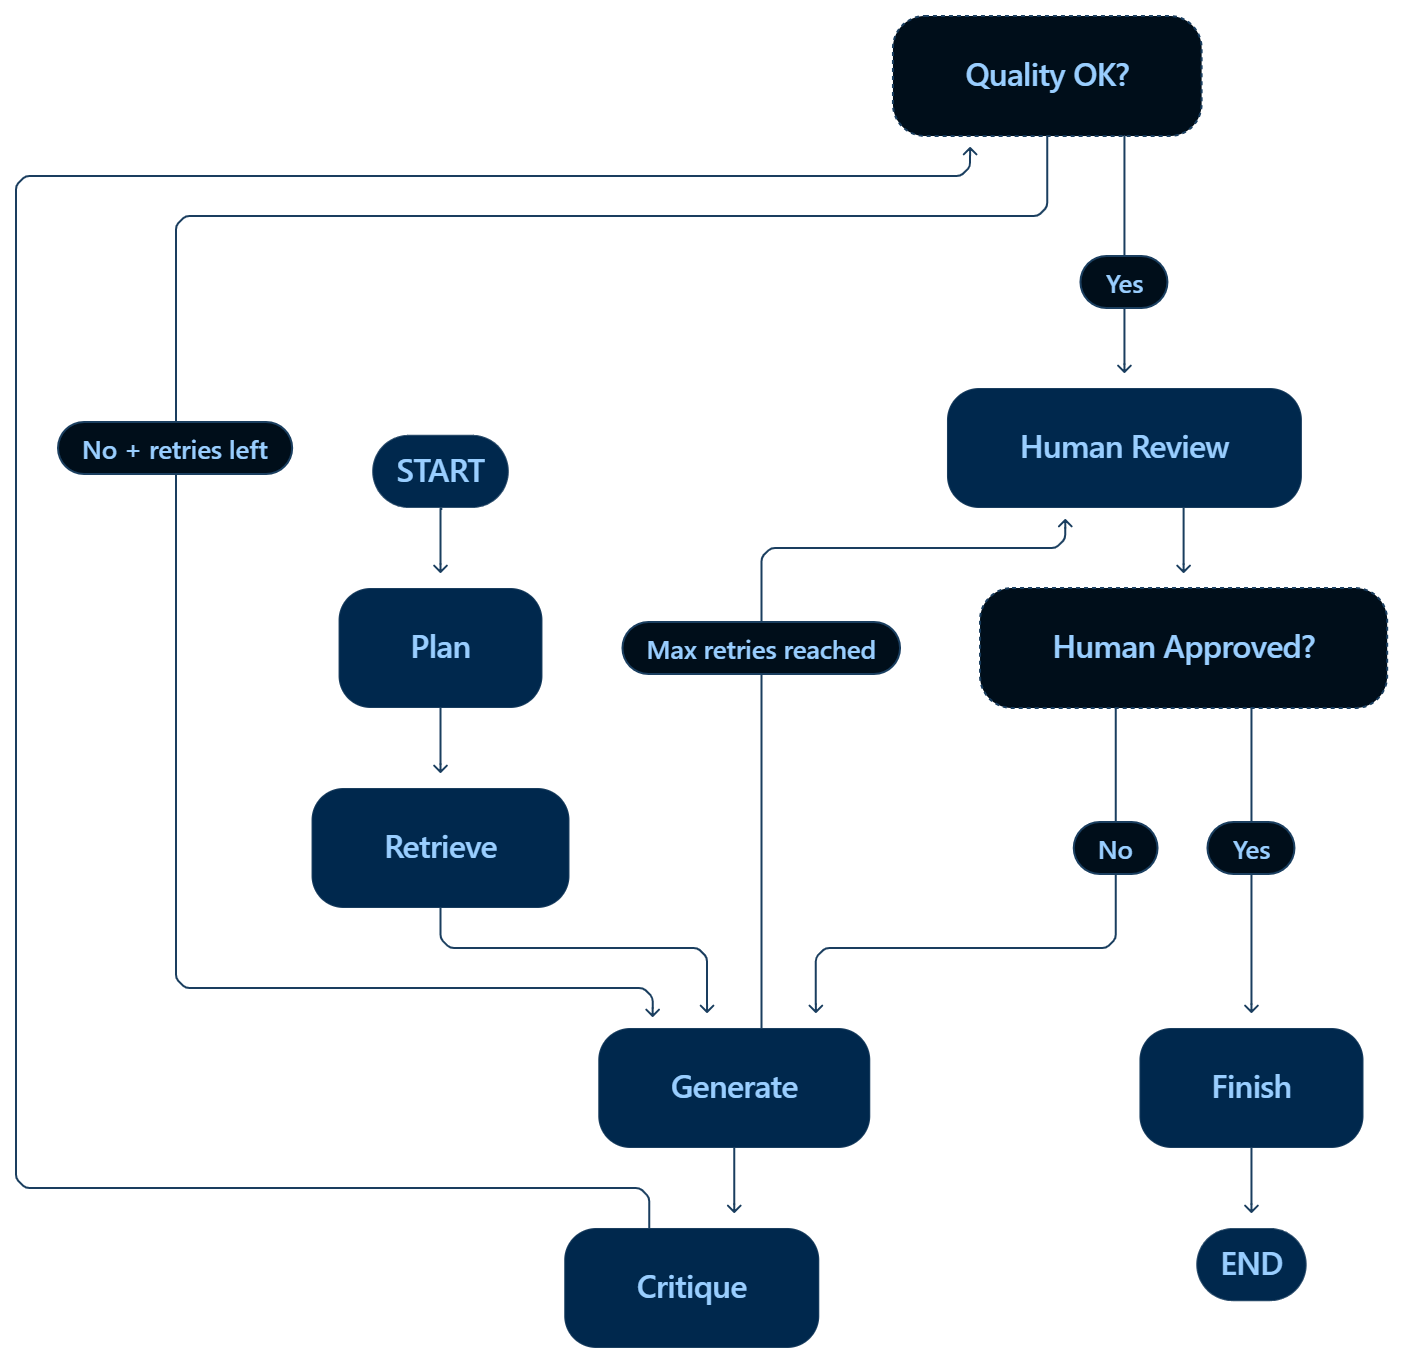

## Planned Workflow

The planned research assistant starts with a user question and passes it through several processing stages. The `Plan` node creates a plan, while the `Retrieve` node gathers relevant information. The `Generate` node creates an answer draft, and the `Critique` node evaluates its quality.
If the quality is below the required threshold and retries are available, the graph loops back to the `Generate` node for self-correction. If the answer is acceptable, the workflow moves to human review. The human can approve the answer and finish the workflow or reject it and send it back for another generation cycle.
